In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import style
style.use('fivethirtyeight')
%matplotlib inline
import glob
import os
from collections import Counter
import pandas as pd
import time

In [3]:
# to desaturate the image by turning pixel into black and white based on the average of the RGB values
# lighter pixels will be turned into white and darker pixels will be turned into black
def threshold(img_array):
  row_avg = []
  for eachrow in img_array:
    row_avg.append(np.average(eachrow))
  avg_color = np.mean(row_avg)
  # print(avg_color)
  new_image = np.eye(len(img_array))

  for row in range(len(img_array)):
    for pixel in range(len(img_array[row])):
      if img_array[row][pixel][0] < avg_color:
        new_image[row][pixel] = 255
      else:
        new_image[row][pixel] = 0
  new_image =np.array(new_image)
  return new_image

In [4]:
# a slightly different code block to threushold ,same principle , just a different way to do it
def threshold2(img_array):
  new =  np.eye(len(img_array))
  rowavg = []
  for eachrow in img_array:
    rowavg.append(np.average(eachrow))
  avgcolor = np.mean(rowavg)
  for row in range(len(img_array)):
    for pixel in range(len(img_array[row])):
      if np.mean(img_array[row][pixel]) >= avgcolor:
        new[row][pixel] = 255
      else:
        new[row][pixel] = 0
  new = np.array(new)
  return new

In [5]:
# to read the entire pixel row of the image and give value to that pixel based on the average of the RGB values of that pixel
# these values will be then passed to the knn algorithm to be trained and tested
def value(row):
  sum = 0
  for i in range(len(row)):
    sum += row[i]/float(i+1)
  return sum

In [6]:
# to read the training images and extracting data out of each image 
# change  this path to where 

In [63]:
# loading the extracted data on the program
df = pd.read_csv('train_file21.csv')

# repalce all missing data  with NAN values
df.replace('?', np.nan, inplace=True)

# deleting the column with id , 1 in the argument indicates "column",so this will delete the column with id
# df.drop(['id'],1, inplace=True)
df.drop(columns=df.columns[[1, 2, 3, 4, 25, 26, 27, 28]], inplace=True)

# delete all rows that have NAN in them
dk = df.dropna()
full_data = dk.values.tolist()
headers = df.dtypes.index
header =  headers.tolist()
header2 = header[:-1]


In [24]:
points = []
for column in df.columns:
  points.append(df[column].tolist())

In [9]:
for point in points:
  del point[0]

In [26]:
# to arrage the data into a knn acceptable format
def new_func():
    dataset = {}
    for i in range (1,len(df)):
      point = []
      label = df.loc[[i]]['label'].tolist()[0]
      if label not in dataset:
        dataset[label] = []
      for head in header2:
        point.append(df.loc [[i]][head].tolist()[0])
      dataset[label].append(point)




In [12]:
# to count the appperence of element for knn
def class_count(data):
  count = {}
  for row in data:
    label = row 
    if label not in count:
      count[label] = 0
    count[label] += 1
  return count

In [34]:
def k_nearest_neighbors(data, predict, k):
  dist = []
  rev = {}
  for group in data:
    for features in data[group]:
      distance = np.linalg.norm(np.array(features)-np.array(predict))
      dist.append([distance, group])
  votes = [i[1] for i in sorted(dist)[:k]]
  uniquevotes = class_count(votes)

# print ('sorted distance: ', sorted(dist))
# print ('votes: ', uniquevotes)

  for vote in uniquevotes:
    rev[uniquevotes[vote]] = vote
  return rev[max(rev)]


In [35]:
from scipy import datasets


image = 'main.jpg'
def predict(image, show = False):
  img = Image.open(image)
  if show :
    print('input image :')
    plt.grid(False)
    plt.imshow(img)
    plt.show()
  pred = []
  image_array = np.array(img)
  try:
    image_t = threshold(image_array)
  except:
    image_t = threshold2(image_array)
  image_t_list = image_t.tolist()
  for row_data in image_t_list:
    pred.append(value(row_data))
  pred = pred[4:24]
  # pred
  answer = k_nearest_neighbors(datasets, pred, 21)

  # print('predicted label: ', answer)
  return answer
# return answer

  



input image :


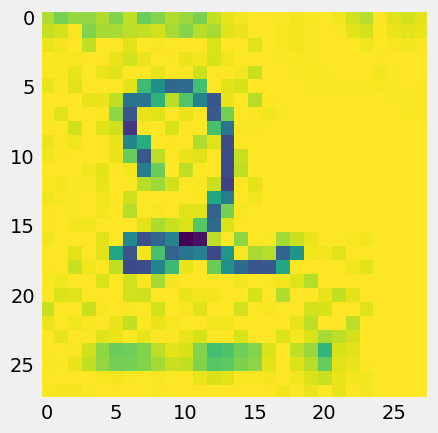

answer :  0


In [69]:
# path = 'main.jpg'
path = '2imag.jpg'
img = Image.open(path).convert('L').resize((28, 28))
path_resized = 'resized.jpg'
img.save(path_resized)

# Corrected predict logic to match dataset feature length (776)
image = path_resized
show = True
img = Image.open(image)
if show:
  print('input image :')
  plt.grid(False)
  plt.imshow(img)
  plt.show()
pred = []
image_array = np.array(img)
try:
  image_t = threshold(image_array)
except:
  image_t = threshold2(image_array)
flattened = image_t.flatten().tolist()
dropped_indices = [1, 2, 3, 4, 25, 26, 27, 28]
pred = [flattened[i] for i in range(len(flattened)) if i not in dropped_indices]
answer = k_nearest_neighbors(dataset, pred, 21)
print('answer : ', answer)